In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction
import plotly.graph_objects as go
import numpy as np

def extract_rule_tp_rates(file_path):
    """
    Extracts rule names and their TP rates from a YARA rule file.
    Returns a dictionary mapping rule names to TP rates (as floats).
    """
    rule_tp_map = {}
    try:
        with open(file_path, 'r') as file:
            content = file.read()
            # Split content into rules, capturing rule name and content
            rules = re.split(r'\n\s*rule\s+([^\s{]+)', content.strip())
            # Pair rule names with their content (name, content, name, content, ...)
            rules = [(rules[i], rules[i+1]) for i in range(1, len(rules), 2)]
            
            for rule_name, rule_content in rules:
                # Validate rule name
                if not rule_name or not re.match(r'^\w+$', rule_name):
                    print(f"Skipping invalid rule name: {rule_name}")
                    continue
                
                # Extract TP rate from comments
                # Match either "//Input TP Rate: X/Y" or standalone "//X/Y"
                tp_match = re.search(
                    r'//\s*(?:Input\s+TP\s+Rate\s*:\s*)?(\d+)\s*/\s*(\d+)', 
                    rule_content, 
                    re.MULTILINE | re.IGNORECASE
                )
                if tp_match:
                    numerator, denominator = map(int, tp_match.groups())
                    tp_rate = Fraction(numerator, denominator) if denominator != 0 else 0
                    rule_tp_map[rule_name] = float(tp_rate)
                else:
                    rule_tp_map[rule_name] = None
                    print(f"Warning: No TP rate found for rule {rule_name}")
                    print(f"Rule content preview:\n{rule_content[:200]}...\n")
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    
    return rule_tp_map

In [2]:
pwd

'/home/mabon/research/Autoyara/AutoPYara/AutoPYara'

In [3]:
def rules_to_dataframe(rule_tp_map, max_runs=30, max_cluster_num=8874):
    """
    Converts a rule-to-TP-rate map into a DataFrame with clusters as rows and runs as columns.
    Includes all clusters from Cluster0 to Cluster{max_cluster_num}, filling missing rows with 0.
    Sorts rows by the numeric part of cluster names (e.g., Cluster0, Cluster1, Cluster2).
    
    Args:
        rule_tp_map (dict): Dictionary mapping rule names (e.g., 'Cluster0_1') to TP rates.
        max_runs (int): Maximum number of runs (default: 30).
        max_cluster_num (int): Maximum cluster number (default: 9000).
    
    Returns:
        pd.DataFrame: DataFrame with clusters as rows, runs as columns, and TP rates as values.
    """
    # Extract clusters and runs
    data = []
    for rule, tp_rate in rule_tp_map.items():
        try:
            cluster, run = rule.rsplit('_', 1)
            run = int(run)
            data.append({'cluster': cluster, 'run': run, 'tp_rate': tp_rate if tp_rate is not None else 0})
        except ValueError:
            print(f"Skipping invalid rule format: {rule}")
            continue
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Pivot to get clusters as rows and runs as columns
    pivot_df = df.pivot(index='cluster', columns='run', values='tp_rate')
    
    # Ensure all columns from 1 to max_runs exist
    columns = list(range(1, max_runs + 1))
    pivot_df = pivot_df.reindex(columns=columns, fill_value=0)
    
    # Fill NaN values (missing TP rates) with 0
    pivot_df = pivot_df.fillna(0)
    
    # Create index with all clusters from Cluster0 to Cluster{max_cluster_num}
    all_clusters = [f'Cluster{i}' for i in range(max_cluster_num + 1)]
    pivot_df = pivot_df.reindex(index=all_clusters, fill_value=0)
    
    # Sort index by numeric part of cluster name
    def extract_cluster_number(cluster_name):
        try:
            number = int(re.search(r'\d+', cluster_name).group())
            return number
        except (AttributeError, ValueError):
            print(f"Warning: Could not extract number from cluster name: {cluster_name}")
            return float('inf')
    
    pivot_df = pivot_df.sort_index(key=lambda x: [extract_cluster_number(name) for name in x])
    
    return pivot_df

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages
def plot_cluster_std_dev_boxplot_static(df, output_file='cluster_std_dev_boxplot.pdf'):
    """
    Generate a static Matplotlib boxplot of standard deviations for each cluster size.
    Saves the output as a machine-readable PDF.

    Parameters:
    - df: pandas DataFrame with cluster sizes as column headers and standard deviations as values
    - output_file: file path to save the PDF
    """
    if not isinstance(df, pd.DataFrame):
        raise ValueError("Input must be a pandas DataFrame")

    # Sort and clean data
    sizes = sorted(df.columns.astype(int).tolist())
    datasets = [df[size].dropna().tolist() for size in sizes]

    # Filter out sizes with no data
    sizes_with_data = [s for s, d in zip(sizes, datasets) if d]
    datasets_with_data = [d for d in datasets if d]

    if not sizes_with_data:
        print("No cluster sizes with valid data found.")
        return

    # Create a single boxplot
    fig, ax = plt.subplots(figsize=(max(10, len(sizes_with_data) * 0.5), 6))
    ax.boxplot(datasets_with_data, labels=[str(s) for s in sizes_with_data], patch_artist=True)
    ax.set_title('Boxplot of Standard Deviations by Cluster Size')
    ax.set_xlabel('Cluster Size (Number of Items)')
    ax.set_ylabel('Standard Deviation of Cluster Averages')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save to PDF
    fig.savefig(output_file, format='pdf')
    plt.close(fig)

    print(f"Static PDF plot saved to {output_file}")

In [10]:
#PLOT FOR INDIVIDUAL CLUSRERS

def plot_cluster_std_dev_boxplot(df, batch_size=10, output_file='cluster_std_dev_boxplot.html'):
    """
    Generate an interactive Plotly boxplot for each cluster size (column) in the DataFrame.
    Each boxplot shows the distribution of standard deviations for that cluster size across rows.
    Includes a batch system to view boxplots in groups and interactive statistics on hover.
    
    Parameters:
    - df: DataFrame with columns as cluster sizes and rows containing standard deviations
    - batch_size: Number of cluster sizes per batch (default: 10)
    - output_file: File path to save the plot (default: 'cluster_std_dev_boxplot.html')
                   Use '.html' for interactive plot, or '.png' for static image (requires kaleido)
    """
    # Validate input
    if not isinstance(df, pd.DataFrame):
        raise ValueError("Input must be a pandas DataFrame")

    # Prepare data for boxplots
    sizes = sorted(df.columns.astype(int).tolist())  # Cluster sizes (sorted)
    datasets = []
    stats_list = []
    for size in sizes:
        # Extract non-NaN values for this cluster size
        data = df[size].dropna().tolist()
        # Compute statistics for hover
        if data:
            stats = {
                'mean': np.mean(data),
                'median': np.median(data),
                'min': np.min(data),
                'max': np.max(data),
                'q1': np.percentile(data, 25),
                'q3': np.percentile(data, 75),
            }
        else:
            stats = {'mean': np.nan, 'median': np.nan, 'min': np.nan, 'max': np.nan, 'q1': np.nan, 'q3': np.nan}
        datasets.append(data)
        stats_list.append(stats)
    
    # Filter out sizes with no data
    sizes_with_data = []
    datasets_with_data = []
    stats_with_data = []
    for size, data, stats in zip(sizes, datasets, stats_list):
        if data:  # Only include sizes with at least one value
            sizes_with_data.append(size)
            datasets_with_data.append(data)
            stats_with_data.append(stats)
    
    if not sizes_with_data:
        print("No cluster sizes with valid data found.")
        return
    
    # Create batches
    batches = []
    for i in range(0, len(sizes_with_data), batch_size):
        batch_sizes = sizes_with_data[i:i + batch_size]
        batch_datasets = datasets_with_data[i:i + batch_size]
        batch_stats = stats_with_data[i:i + batch_size]
        batches.append({
            'sizes': batch_sizes,
            'datasets': batch_datasets,
            'stats': batch_stats,
            'label': f'Sizes {batch_sizes[0]}-{batch_sizes[-1]}'
        })
    
    # Add "All Sizes" batch
    batches.append({
        'sizes': sizes_with_data,
        'datasets': datasets_with_data,
        'stats': stats_with_data,
        'label': 'All Sizes'
    })
    
    # Create the Plotly figure
    fig = go.Figure()
    
    # Add traces for all data (initially showing the first batch)
    for batch in batches:
        for size, data, stats in zip(batch['sizes'], batch['datasets'], batch['stats']):
            # Format stats for hover
            hover_text = (
                f"Size: {size}<br>"
                f"Mean: {stats['mean']:.2f}<br>"
                f"Median: {stats['median']:.2f}<br>"
                f"Min: {stats['min']:.2f}<br>"
                f"Max: {stats['max']:.2f}<br>"
                f"Q1: {stats['q1']:.2f}<br>"
                f"Q3: {stats['q3']:.2f}"
            )
            fig.add_trace(
                go.Box(
                    y=data,
                    name=str(size),
                    boxpoints='all',  # Show all points
                    jitter=0.3,  # Spread points for visibility
                    pointpos=-1.8,  # Position points to the left of the box
                    marker=dict(color='navy'),
                    line=dict(color='navy'),
                    fillcolor='skyblue',
                    width=0.6,
                    hoverinfo='text',
                    text=hover_text,
                    visible=(batch == batches[0])  # Only first batch visible initially
                )
            )
    
    # Create dropdown menu for batches
    updatemenus = [
        dict(
            buttons=[
                dict(
                    label=batch['label'],
                    method='update',
                    args=[
                        {'visible': [
                            (batch == b) for b in batches for _ in b['sizes']
                        ]},
                        {
                            'xaxis.tickvals': list(range(len(batch['sizes'])))[::max(1, len(batch['sizes']) // 10)],
                            'xaxis.ticktext': [str(size) for size in batch['sizes']][::max(1, len(batch['sizes']) // 10)],
                            'xaxis.tickangle': 45
                        }
                    ]
                )
                for batch in batches
            ],
            direction='down',
            showactive=True,
            x=0.1,
            xanchor='left',
            y=1.15,
            yanchor='top'
        )
    ]
    
    # Update layout
    max_y = max([max(data) for data in datasets_with_data if data]) * 1.1  # Adjust y-axis
    first_batch = batches[0]
    tick_interval = max(1, len(first_batch['sizes']) // 10)
    fig.update_layout(
        title="Boxplot of Standard Deviations by Cluster Size",
        xaxis_title="Cluster Size (Number of Items)",
        yaxis_title="Standard Deviation of Cluster Averages",
        xaxis=dict(
            tickmode='array',
            tickvals=list(range(len(first_batch['sizes'])))[::tick_interval],
            ticktext=[str(size) for size in first_batch['sizes']][::tick_interval],
            tickangle=45
        ),
        yaxis=dict(range=[0, max_y]),
        showlegend=False,
        updatemenus=updatemenus
    )
    
    # Save the plot
    fig.write_html(output_file)
    print(f"Plot saved as {output_file}")
csv_file='/home/mabon/research/Autoyara/AutoPYara/AutoPYara/clusters/sdhash/th50.csv'
df1 = pd.read_csv(csv_file)
labels = df1['Cluster_Label'].dropna().astype(int).tolist()  # Ensure integers
cluster_sizes = {label: labels.count(label) for label in set(labels) if label >= 0}

# Filter for clusters with size >= 2 (keep the key-value pairs)
data = {label: size for label, size in cluster_sizes.items() if size >= 2}
unique_vals =sorted(set(data.values()))
df_new  = pd.DataFrame(columns=unique_vals)

print(df_new.head(4))

file_path = '/home/mabon/research/Autoyara/AutoPYara/AutoPYara/yaraEval/Th50rules/merged_group_1.yar'
result = extract_rule_tp_rates(file_path)
# for rule_name, tp_rate in result.items():
#     print(f"Rule: {rule_name}, TP Rate: {tp_rate}")
df_cluster = rules_to_dataframe(result, max_runs=30,max_cluster_num=len(data))
df_cluster=df_cluster.transpose()
df_cluster=df_cluster.mean(numeric_only=True)

# Step 3: Populate the new DataFrame
for cluster_name, score in df_cluster.items():
    # Extract the key (e.g., Cluster0 → 0)
    key = int(cluster_name.replace('Cluster', ''))
    if key in data:
        col = data[key]
        # Find first available empty row index (or append a new one)
        row_idx = df_new.index[df_new[col].isna()].min() if col in df_new.columns and not df_new.empty else None
        if pd.isna(row_idx):
            row_idx = len(df_new)
            df_new.loc[row_idx] = [None] * len(df_new.columns)
        df_new.at[row_idx, col] = score
plot_cluster_std_dev_boxplot_static(df_new,output_file='sdhashth50_B.pdf')

Empty DataFrame
Columns: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 59, 60, 62, 63, 64, 67, 68, 74, 77, 78, 80, 82, 88, 91, 93, 99, 100, 110, 111, 115, 116, 118, 120, 128, 151, 157, 170, 174, 200, 210, 212, 220, 223, 224, 263, 300, 306, 355, 475, 639, 648, 689, 1125]
Index: []

[0 rows x 97 columns]
Static PDF plot saved to sdhashth50_B.pdf


In [9]:
csv_file='/home/mabon/research/Autoyara/AutoPYara/AutoPYara/clusters/ssdeep/c'
df1 = pd.read_csv(csv_file)
labels = df1['Cluster_Label'].dropna().astype(int).tolist()  # Ensure integers
cluster_sizes = {label: labels.count(label) for label in set(labels) if label >= 0}

# Filter for clusters with size >= 2 (keep the key-value pairs)
data = {label: size for label, size in cluster_sizes.items() if size >= 2}
unique_vals =sorted(set(data.values()))
df_new  = pd.DataFrame(columns=unique_vals)

print(df_new.head(4))

file_path = '/home/mabon/research/Autoyara/AutoPYara/AutoPYara/yaraEval/Th90rules/merged_group_1.yar'
result = extract_rule_tp_rates(file_path)
# for rule_name, tp_rate in result.items():
#     print(f"Rule: {rule_name}, TP Rate: {tp_rate}")
df_cluster = rules_to_dataframe(result, max_runs=30,max_cluster_num=len(data))
df_cluster=df_cluster.transpose()
df_cluster=df_cluster.mean(numeric_only=True)

# Step 3: Populate the new DataFrame
for cluster_name, score in df_cluster.items():
    # Extract the key (e.g., Cluster0 → 0)
    key = int(cluster_name.replace('Cluster', ''))
    if key in data:
        col = data[key]
        # Find first available empty row index (or append a new one)
        row_idx = df_new.index[df_new[col].isna()].min() if col in df_new.columns and not df_new.empty else None
        if pd.isna(row_idx):
            row_idx = len(df_new)
            df_new.loc[row_idx] = [None] * len(df_new.columns)
        df_new.at[row_idx, col] = score
plot_cluster_std_dev_boxplot_static(df_new,output_file='plots/th90.pdf')

Empty DataFrame
Columns: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 47, 49, 50, 51, 60, 62, 68, 70, 79, 88, 90, 91, 94, 96, 109, 135, 144, 152, 154, 158, 218, 242, 249, 263, 299, 378, 466]
Index: []

[0 rows x 69 columns]
Static PDF plot saved to plots/th90.pdf


In [39]:
# # Replace None with NaN if needed
# df = df_new.replace({None: pd.NA})

# # Drop columns with only one non-null value
# df = df.loc[:, df.count() > 1]
# df = df.replace({pd.NA: None, pd.NaT: None, pd.NaT: None, 'NaN': None})
#plot_cluster_std_dev_boxplot(df_new,output_file='cluster_std_dev_boxplot.html')

Plot saved as cluster_std_dev_boxplot.html


In [ ]:
def get_files_by_all_clusters(df):
    """
    Get all file paths organized by their cluster labels, sorted by cluster size in descending order.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing File_Path and Cluster_Label columns
    
    Returns:
    dict: Dictionary where keys are cluster labels and values are lists of file paths,
          ordered by cluster size (largest to smallest)
    """
    # Group by Cluster_Label and get lists of File_Path
    clustered_files = df.groupby('Cluster_Label')['File_Path'].apply(list).to_dict()
    
    # Sort by length of file lists and create new ordered dictionary
    sorted_items = sorted(clustered_files.items(), key=lambda x: len(x[1]), reverse=True)
    return dict(sorted_items)


df = pd.read_csv(csv_file)
# Get files organized by clusters
all_cluster_files = get_files_by_all_clusters(df)
    # Filter out clusters with fewer than two elements
valid_clusters= {k: v for k, v in all_cluster_files.items() if len(v) >= 2}

# # Display the sorted cluster labels
# print(sorted_cluster_labels)


file_path = '/home/mabon/research/Autoyara/AutoPYara/AutoPYara/yaraEval/Th90rules/merged_group_1.yar'
result = extract_rule_tp_rates(file_path)
# for rule_name, tp_rate in result.items():
#     print(f"Rule: {rule_name}, TP Rate: {tp_rate}")
df = rules_to_dataframe(result, max_runs=30)
df=df.transpose()

# Convert labels to column names
sorted_cluster_columns = [f'Cluster{label}' for label in sorted_cluster_labels]

# Filter columns that actually exist in the DataFrame
existing_sorted_columns = [col for col in sorted_cluster_columns if col in df.columns]

# Keep only those columns (and optionally keep index/run column)
columns_to_keep = ['run'] + existing_sorted_columns if 'run' in df.columns else existing_sorted_columns
df_filtered = df[columns_to_keep]
import plotly.graph_objects as go
import pandas as pd

# Drop the 'run' column if it exists
cluster_data = df_filtered.drop(columns=['run']) if 'run' in df_filtered.columns else df_filtered

# Group columns into chunks of 1000 for dropdown filtering
chunk_size = 1000
cluster_names = list(cluster_data.columns)
chunks = [cluster_names[i:i + chunk_size] for i in range(0, len(cluster_names), chunk_size)]

# Create figure with only the first chunk visible
fig = go.Figure()

for idx, chunk in enumerate(chunks):
    visible = [idx == 0] * len(chunk)  # Only first chunk visible initially
    for col in chunk:
        fig.add_trace(go.Box(
            y=cluster_data[col],
            name=str(col),
            boxpoints='outliers',
            marker=dict(size=2),
            line=dict(width=1),
            whiskerwidth=0.5,
            visible=idx == 0
        ))

# Create dropdown for chunk selection
dropdown_buttons = []
trace_index = 0
for idx, chunk in enumerate(chunks):
    visibility = []
    for i, c in enumerate(chunks):
        visibility.extend([j == idx for j in [i]*len(c)])  # Only one chunk visible
    dropdown_buttons.append(
        dict(
            label=f"Clusters {chunk[0]} - {chunk[-1]}",
            method="update",
            args=[{"visible": visibility},
                  {"title": f"Box Plot of Clusters {chunk[0]} - {chunk[-1]}"}]
        )
    )

# Update layout
fig.update_layout(
    title=f"Box Plot of Clusters {chunks[0][0]} - {chunks[0][-1]}",
    xaxis_title="Clusters",
    yaxis_title="Values",
    showlegend=False,
    margin=dict(l=40, r=40, t=60, b=160),
    xaxis=dict(tickangle=45, tickfont=dict(size=9), automargin=True),
    height=600,
    width=1400,
    updatemenus=[
        dict(
            active=0,
            buttons=dropdown_buttons,
            direction="down",
            x=1.05,
            xanchor="left",
            y=1.1,
            yanchor="top"
        )
    ]
)

# Save interactive HTML
fig.write_html("plots/Zersos_TH90.html")
import plotly.graph_objects as go
import pandas as pd

# Drop the 'run' column if it exists
cluster_data = df_filtered.drop(columns=['run']) if 'run' in df_filtered.columns else df_filtered

# Drop 0 values per column (i.e., treat 0 as "missing" or "not relevant")
cluster_data_no_zeros = cluster_data.apply(lambda col: col[col != 0], axis=0)

# Group columns into chunks of 1000
chunk_size = 1000
cluster_names = list(cluster_data_no_zeros.columns)
chunks = [cluster_names[i:i + chunk_size] for i in range(0, len(cluster_names), chunk_size)]

# Build figure
fig = go.Figure()

# Add traces for each chunk (initially only first visible)
for idx, chunk in enumerate(chunks):
    for col in chunk:
        y_vals = cluster_data_no_zeros[col].dropna()
        fig.add_trace(go.Box(
            y=y_vals,
            name=str(col),
            boxpoints='outliers',
            marker=dict(size=2),
            line=dict(width=1),
            whiskerwidth=0.5,
            visible=(idx == 0)
        ))

# Dropdown buttons to toggle chunks
dropdown_buttons = []
trace_index = 0
for idx, chunk in enumerate(chunks):
    visibility = []
    for c_idx, c in enumerate(chunks):
        visibility.extend([idx == c_idx] * len(c))  # Only the selected chunk is visible
    dropdown_buttons.append(
        dict(
            label=f"Clusters {chunk[0]} - {chunk[-1]}",
            method="update",
            args=[{"visible": visibility},
                  {"title": f"Box Plot of Clusters {chunk[0]} - {chunk[-1]} (No Zeros)"}]
        )
    )

# Layout improvements
fig.update_layout(
    title=f"Box Plot of Clusters {chunks[0][0]} - {chunks[0][-1]} (No Zeros)",
    xaxis_title="Clusters",
    yaxis_title="Values",
    showlegend=False,
    margin=dict(l=40, r=40, t=60, b=160),
    xaxis=dict(tickangle=45, tickfont=dict(size=9), automargin=True),
    height=600,
    width=1400,
    updatemenus=[
        dict(
            active=0,
            buttons=dropdown_buttons,
            direction="down",
            x=1.05,
            xanchor="left",
            y=1.1,
            yanchor="top"
        )
    ]
)

# Save as HTML
fig.write_html("plots/NONZersos_TH90.html")


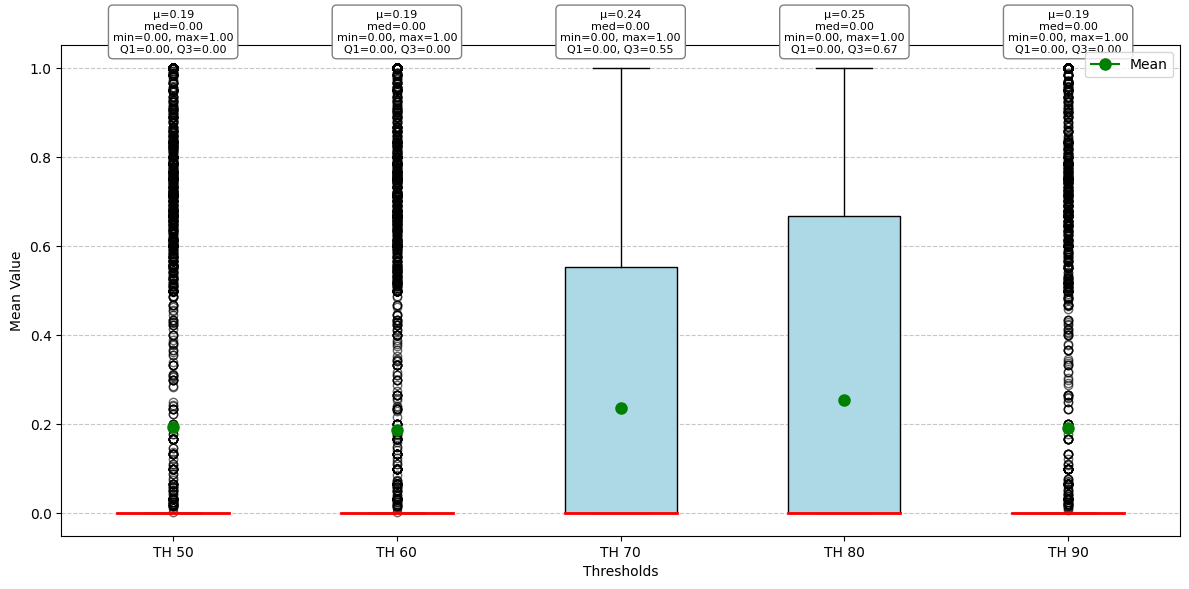

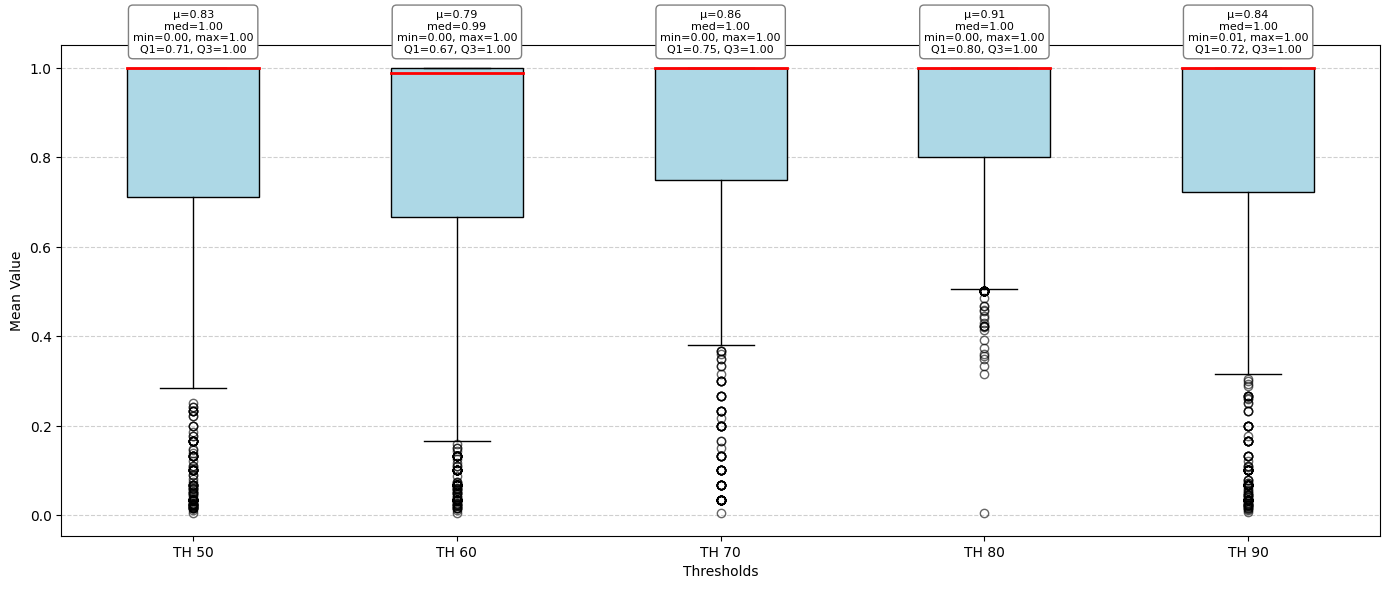

In [7]:
# List of file paths for the YARA rule files
file_paths = [
    '/home/mabon/research/Autoyara/AutoPYara/AutoPYara/yaraEval/Th50rules/merged_group_1.yar',
    '/home/mabon/research/Autoyara/AutoPYara/AutoPYara/yaraEval/Th60rules/merged_group_1.yar',
    '/home/mabon/research/Autoyara/AutoPYara/AutoPYara/yaraEval/Th70rules/merged_group_1.yar',
    '/home/mabon/research/Autoyara/AutoPYara/AutoPYara/yaraEval/Th80rules/merged_group_1.yar',
    '/home/mabon/research/Autoyara/AutoPYara/AutoPYara/yaraEval/Th90rules/merged_group_1.yar'
]

# Initialize an empty list to hold the dataframes
dfs = []

# Iterate through the file paths and process each file
for file_path in file_paths:
    result = extract_rule_tp_rates(file_path)
    df = rules_to_dataframe(result, max_runs=30)
    dfs.append(df)

# Calculate the transposed mean for each dataframe
df_transposed_means = [df.transpose().mean(axis=0) for df in dfs]



import matplotlib.pyplot as plt
import numpy as np

# Your five lists of mean values
data = df_transposed_means

# Plot
plt.figure(figsize=(12, 6))
box = plt.boxplot(data, patch_artist=True)

# Style
colors = ['lightblue'] * 5
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Outlier style
for flier in box['fliers']:
    flier.set(marker='o', color='black', alpha=0.6)

# Median line style
for median in box['medians']:
    median.set(color='red', linewidth=2)

# Updated x-axis labels
plt.xticks(ticks=[1, 2, 3, 4, 5], labels=['TH 50', 'TH 60', 'TH 70', 'TH 80', 'TH 90'])

# Adding mean markers
means = [np.mean(d) for d in data]
for i, mean in enumerate(means):
    plt.plot(i + 1, mean, marker='o', color='green', markersize=8, label='Mean' if i == 0 else "")

# Add statistical annotations
for i, dataset in enumerate(data):
    stats = {
        'mean': np.mean(dataset),
        'median': np.median(dataset),
        'min': np.min(dataset),
        'max': np.max(dataset),
        'q1': np.percentile(dataset, 25),
        'q3': np.percentile(dataset, 75),
    }

    y_pos = stats['max'] + 0.03  # Position text above the whisker
    text = (
        f"μ={stats['mean']:.2f}\n"
        f"med={stats['median']:.2f}\n"
        f"min={stats['min']:.2f}, max={stats['max']:.2f}\n"
        f"Q1={stats['q1']:.2f}, Q3={stats['q3']:.2f}"
    )
    plt.text(i + 1, y_pos, text, ha='center', va='bottom', fontsize=8, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.4'))

# Titles and labels
# plt.title("Variation of Mean and Median Values Across Datasets with Statistical Annotations")
plt.xlabel("Thresholds")
plt.ylabel("Mean Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display legend for mean
plt.legend()

plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import numpy as np

# List of transposed mean dataframes
datasets = [
    df[df != 0].dropna() for df in df_transposed_means
]

labels = ['TH 50', 'TH 60', 'TH 70', 'TH 80', 'TH 90']

# Generate plot
plt.figure(figsize=(14, 6))
box = plt.boxplot(datasets, patch_artist=True)

# Color styling
for patch in box['boxes']:
    patch.set_facecolor('lightblue')
for flier in box['fliers']:
    flier.set(marker='o', color='black', alpha=0.6)
for median in box['medians']:
    median.set(color='red', linewidth=2)

# Add stats as annotations
for i, data in enumerate(datasets):
    stats = {
        'mean': np.mean(data),
        'median': np.median(data),
        'min': np.min(data),
        'max': np.max(data),
        'q1': np.percentile(data, 25),
        'q3': np.percentile(data, 75),
    }

    y_pos = stats['max'] + 0.03  # Position text above the whisker
    text = (
        f"μ={stats['mean']:.2f}\n"
        f"med={stats['median']:.2f}\n"
        f"min={stats['min']:.2f}, max={stats['max']:.2f}\n"
        f"Q1={stats['q1']:.2f}, Q3={stats['q3']:.2f}"
    )
    plt.text(i + 1, y_pos, text, ha='center', va='bottom', fontsize=8, bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.4'))

# Labels and title
plt.xticks(ticks=[1, 2, 3, 4, 5], labels=labels)
# plt.title("Boxplot of Non-Zero Mean Values with Stats")
plt.xlabel("Thresholds")
plt.ylabel("Mean Value")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
